<a href="https://colab.research.google.com/github/sheliter/Assignment/blob/main/Homework_07.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Homework 7: Sentiment Classification with Pre-trained and Re-trained GloVe Embeddings

In this notebook, we continue our investigation of text classification using “Bag of Embeddings” models and the IMDB movie review dataset.

Previously, we used pre-trained GloVe embeddings as fixed feature extractors. In this homework, we move to **fine-tuning** those embeddings — allowing gradient updates to adapt the embedding space to the sentiment classification task.

You will explore how model performance is affected by:

- Fine-tuning vs. frozen embeddings  
- Architectural adjustments  
- Vocabulary size and maximum message length  
- Embedding dimensionality  

You'll complete three problems:

- **Problem One:** Build a baseline model with unfrozen embeddings and experiment with architectural and training adjustments to improve performance.
- **Problem Two:** Investigate how increasing the maximum message length and vocabulary size affects model accuracy and generalization.
- **Problem Three:** Examine the impact of changing the embedding dimension on model performance.

In each problem, you will report your best validation accuracy and reflect on what your experiments reveal about model capacity, generalization, and diminishing returns.

### Useful Imports

In [25]:
import os
os.environ['TF_CPP_MIN_LOG_LEVEL'] = '2'
import time
from datetime import datetime
from pathlib import Path
from collections import Counter

import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf

from tensorflow.keras import Sequential, Input
from tensorflow.keras.layers import Embedding, GlobalAveragePooling1D, Dense, Dropout
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.datasets import imdb
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau

from sklearn.model_selection import train_test_split


# -----------------------------
# Reproducibility
# -----------------------------
random_seed = 42
np.random.seed(random_seed)
tf.random.set_seed(random_seed)

# -----------------------------
# Utility: format elapsed time
# -----------------------------
def format_hms(seconds):
    return time.strftime("%H:%M:%S", time.gmtime(seconds))

# Example usage:
# start_time = time.time()
# <your code>
# print("Execution Time:", format_hms(time.time() - start_time))

# Suppress TensorFlow INFO/WARNING messages
os.environ['TF_CPP_MIN_LOG_LEVEL'] = '2'

## GloVe Setup (Auto-Download if Needed)

This notebook will automatically download the GloVe 6B embeddings
if they are not already present (you should have them if you ran the Coding Notebook from Week 7).

In [26]:
import os, zipfile, urllib.request
from pathlib import Path
import numpy as np
from tensorflow.keras.datasets import imdb

# -----------------------------
# GloVe Setup (auto-download)
# -----------------------------
GLOVE_DIR = Path(os.environ.get("GLOVE_DIR", "data/glove")).expanduser()
GLOVE_DIR.mkdir(parents=True, exist_ok=True)

GLOVE_6B_URL = "https://nlp.stanford.edu/data/glove.6B.zip"

def ensure_glove_6b(download_dir: Path) -> Path:
    zip_path = download_dir / "glove.6B.zip"
    extracted_dir = download_dir / "glove.6B"

    if extracted_dir.exists() and any(extracted_dir.glob("glove.6B.*d.txt")):
        return extracted_dir

    if not zip_path.exists():
        print(f"Downloading GloVe 6B to: {zip_path}")
        urllib.request.urlretrieve(GLOVE_6B_URL, zip_path)

    print(f"Extracting: {zip_path} -> {download_dir}")
    with zipfile.ZipFile(zip_path, "r") as zf:
        zf.extractall(download_dir)

    if extracted_dir.exists():
        return extracted_dir
    if any(download_dir.glob("glove.6B.*d.txt")):
        return download_dir

    raise FileNotFoundError("GloVe files not found after extraction.")

def load_glove_vectors(glove_folder: Path, embedding_dimension: int) -> dict:
    glove_path = glove_folder / f"glove.6B.{embedding_dimension}d.txt"
    if not glove_path.exists():
        raise FileNotFoundError(
            f"Missing {glove_path}. Re-run the setup cell or check your GLOVE_DIR."
        )

    embeddings_index = {}
    with glove_path.open(encoding="utf8") as f:
        for line in f:
            word, *vec = line.split()
            embeddings_index[word] = np.asarray(vec, dtype="float32")
    return embeddings_index

def build_embedding_matrix(training_vocabulary_size: int, embedding_dimension: int) -> np.ndarray:
    glove_folder = ensure_glove_6b(GLOVE_DIR)
    embeddings_index = load_glove_vectors(glove_folder, embedding_dimension)

    word_index = imdb.get_word_index()
    embedding_matrix = np.zeros((training_vocabulary_size, embedding_dimension), dtype="float32")

    for word, raw_idx in word_index.items():
        idx = raw_idx + 3
        if idx >= training_vocabulary_size:
            continue
        vec = embeddings_index.get(word)
        if vec is not None:
            embedding_matrix[idx] = vec

    return embedding_matrix

GLOVE_FOLDER = ensure_glove_6b(GLOVE_DIR)
print(f"GloVe folder ready: {GLOVE_FOLDER}")

Extracting: data/glove/glove.6B.zip -> data/glove
GloVe folder ready: data/glove


### Utility function to plot learning curves and keep track of all results

- Call `print_results()` to see listing of all results logged so far
- We've also added  `

In [27]:
def plot_learning_curves(hist, title, verbose=True):

    val_losses = hist.history['val_loss']
    min_val_loss = min(val_losses)
    min_val_epoch = val_losses.index(min_val_loss)
    val_acc_at_min_loss = hist.history['val_accuracy'][min_val_epoch]

    epochs = range(1, len(val_losses) + 1)  # epoch numbers starting at 1

    fig, axs = plt.subplots(2, 1, figsize=(8, 8), sharex=True)

    # --- Loss Plot ---
    axs[0].plot(epochs, hist.history['loss'], label='train loss')
    axs[0].plot(epochs, hist.history['val_loss'], label='val loss')
    axs[0].scatter(min_val_epoch + 1, min_val_loss, color='red', marker='x', s=50, label='min val loss')
    axs[0].set_title(f'{title} - Categorical Cross-Entropy Loss')
    axs[0].set_ylabel('Loss')
    axs[0].legend()
    axs[0].grid(True)

    # --- Accuracy Plot ---
    axs[1].plot(epochs, hist.history['accuracy'], label='train acc')
    axs[1].plot(epochs, hist.history['val_accuracy'], label='val acc')
    axs[1].scatter(min_val_epoch + 1, val_acc_at_min_loss, color='red', marker='x', s=50, label='acc @ min val loss')
    axs[1].set_title(f'{title} - Accuracy')
    axs[1].set_xlabel('Epoch')
    axs[1].set_ylabel('Accuracy')
    axs[1].legend()
    axs[1].grid(True)
    axs[1].set_ylim(0, 1.05)

    plt.tight_layout()
    plt.show()


###  Wrapper for training and testing

#### Assumptions:   
- Early stopping is default, add other callbacks as needed
- Uses "binary_crossentropy" for binary classification task.
- Assumes `X_train,y_train,X_test,y_test` already defined, will access them as global variables.
- If `X_val` and `y_val` defined, will use those, else assumes `validation_split = 0.2` in `fit`


**Note:** See the end of the notebook for results and parameter settings.

In [28]:
def train_and_test(model,
                   title         = "Learning Curves",
                   epochs        = 200,                   # Just needs to be bigger than early stopping point
                   optimizer     = "Adam",
                   lr_schedule   = 1e-3,                  # Adam defaults
                   clipnorm      = None,
                   batch_size    = 128,
                   loss          = "binary_crossentropy",
                   metrics       = ["accuracy"],
                   use_early_stopping = True,
                   patience      = 10,
                   min_delta     = 0.0001,
                   callbacks     = [],                     # for extra callbacks other than early stopping
                   verbose       = 0,
                   return_history = False
                  ):

    print(f"\n{title}\n")

    if optimizer == "Adam":
        opt = Adam(learning_rate=lr_schedule,clipnorm=clipnorm)
    else:
        opt = optimizer

    #Compiling the model
    model.compile(optimizer = opt,
                  loss      = loss,
                  metrics   = metrics
                 )



    if use_early_stopping:
        early_stop = EarlyStopping(
            monitor              = 'val_loss',
            patience             = patience,
            min_delta            = min_delta,
            restore_best_weights = True,               # this will mean that the model which produced the smallest validation loss will be returned
            verbose              = verbose
        )
        cbs=[early_stop] + callbacks
    else:
        cbs=callbacks

    # start timer
    start = time.time()

    # Fit the model with early stopping
    # If X_val defined, then  use it, else assume val is split from train

    if 'X_val' in globals():
        history = model.fit(X_train, y_train,
                            epochs=epochs,
                            batch_size=batch_size,
                            validation_data=(X_val, y_val),
                            callbacks=cbs,
                            verbose=verbose
                           )
    else:
        history = model.fit(X_train, y_train,
                            epochs=epochs,
                            batch_size=batch_size,
                            validation_split=0.2,
                            callbacks=cbs,
                            verbose=verbose
                           )

    # Plot training history
    plot_learning_curves(history, title=title)

    # Find epoch with minimum validation loss
    min_val_epoch = np.argmin(history.history['val_loss'])
    # Retrieve the values at that epoch
    min_val_loss = history.history['val_loss'][min_val_epoch]
    # Get corresponding validation accuracy at that epoch
    val_acc_at_min_loss = history.history['val_accuracy'][min_val_epoch]

    # Evaluate on test data
    test_loss, test_accuracy = model.evaluate(X_test, y_test, verbose=0)

    # Record end time and print execution time
    end = time.time()
    print(f"\nExecution Time: " + format_hms(end-start))

    # Print out results

    print(f"\nFinal Training Loss:            {history.history['loss'][-1]:.4f}")
    print(f"Final Training Accuracy:        {history.history['accuracy'][-1]:.4f}")
    print(f"Final Validation Loss:          {history.history['val_loss'][-1]:.4f}")
    print(f"Final Validation Accuracy:      {history.history['val_accuracy'][-1]:.4f}")
    print(f"Minimum Validation Loss:        {min_val_loss:.4f} (Epoch {min_val_epoch + 1})")
    print(f"Validation Accuracy @ Min Loss: {val_acc_at_min_loss:.4f}")

    print(f"\nTest Loss: {test_loss:.4f}")
    print(f"Test Accuracy: {test_accuracy:.4f}")

    print(f"\nValidation-Test Accuracy Gap: {abs(val_acc_at_min_loss - test_accuracy):.6f}")

    # Store accuracy in results
    results[title] = (val_acc_at_min_loss,min_val_epoch + 1)

    # Store all information about run in parameter_settings

    global parameter_settings
    entry = {
        "title": title,
        "timestamp": datetime.now().isoformat(timespec="seconds"),
        "epochs": int(epochs),
        "optimizer": optimizer,
        "lr_schedule": lr_schedule,
        "clipnorm": clipnorm,
        "loss": loss,
        "batch_size": batch_size,
        "use_early_stopping": use_early_stopping,
        "patience": patience,
        "min_delta": min_delta,
        "callbacks": _summarize_callbacks(callbacks),
        "Final Training Loss" : history.history['loss'][-1],
        "Final Training Accuracy" : history.history['accuracy'][-1],
        "Final Val Loss" : history.history['val_loss'][-1],
        "Final Val Accuracy" : history.history['val_accuracy'][-1],
        "Min Val Loss" : min_val_loss,
        "Min Val Loss Epoch" : min_val_epoch,
        "Val Acc @ Min Loss" : val_acc_at_min_loss,
        "Test Loss" : test_loss,
        "Test Acc" : test_accuracy,
        "Val-Test Accuracy Gap:" : abs(val_acc_at_min_loss - test_accuracy)
    }
    parameter_settings.setdefault(title, []).append(entry)

    if return_history:
        return history

def _summarize_callbacks(cbs):
    if cbs is None:
        return None
    out = []
    for cb in cbs:
        name = getattr(cb, "__class__", type(cb)).__name__
        info = {"class": name}
        # grab a few common attributes if present
        for attr in ("monitor", "mode", "patience", "min_delta",
                     "factor", "min_lr", "verbose", "cooldown"):
            if hasattr(cb, attr):
                info[attr] = getattr(cb, attr)
        out.append(info)
    return out

results = {}
parameter_settings = {}

def print_results():
    for title, (acc, ep) in sorted(results.items(),
                                   key=lambda kv: kv[1][0],   # kv[1] is (acc, epoch); [0] is acc
                                   reverse=True
                                  ):
        print(f"{title:<40}\t{acc:.4f}\t{ep}")

In [29]:
reduce_lr = ReduceLROnPlateau(
    monitor='val_loss',    # Quantity to be monitored.
    factor=0.5,            # Factor by which the learning rate will be reduced.
                           # new_lr = lr * factor
    patience=5,            # Number of epochs with no improvement
                           # after which learning rate will be reduced.
    min_delta=1e-5,        # Threshold for measuring the new optimum,
                           # to only focus on significant changes.
    cooldown=0,            # Number of epochs to wait before resuming
                           # normal operation after lr has been reduced.
    min_lr=1e-8,           # Lower bound on the learning rate.
    verbose=1,             # 0: quiet, 1: update messages.
)

#  put in the callbacks list:

#    train_and_test(model, title="Learning Curves",callbacks=[reduce_lr])


### Prelude:  A little EDA: Distribution of review lengths and coverage by max vocabulary size

You will use this to think about where the set parameters for maximum review length and the maximum number of unique tokens to use.


Total unique words in Keras IMDB word_index (corpus-wide): 88,584
Num training reviews: 25,000
Max length: 2,494 tokens
Mean length: 238.7 tokens
Median length: 178 tokens
90th percentile: 467 tokens
95th percentile: 610 tokens
99th percentile: 926 tokens


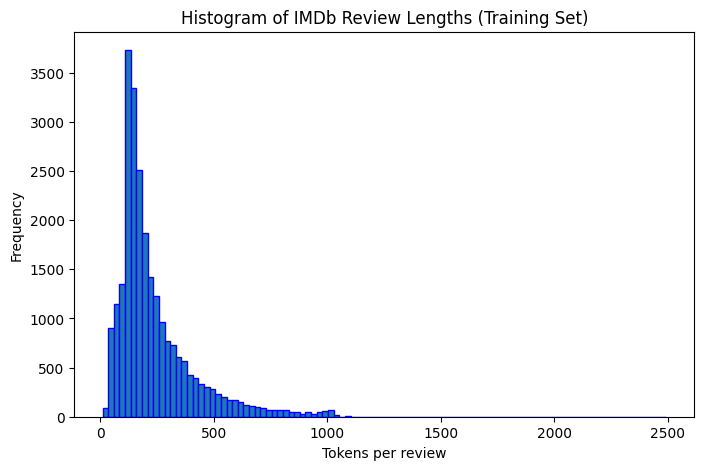


Unique word types in TRAIN (id >= 3): 88,583
Total word tokens in TRAIN (id >= 3): 5,942,840

Coverage metrics by candidate vocab size (TRAIN split):
training_vocabulary_size= 2,000 | coverage= 82.84% | OOV= 17.16% | types kept=  1,997 | tokens kept= 4,922,766
training_vocabulary_size= 5,000 | coverage= 90.03% | OOV=  9.97% | types kept=  4,997 | tokens kept= 5,350,551
training_vocabulary_size=10,000 | coverage= 94.25% | OOV=  5.75% | types kept=  9,997 | tokens kept= 5,601,261
training_vocabulary_size=20,000 | coverage= 97.22% | OOV=  2.78% | types kept= 19,997 | tokens kept= 5,777,376
training_vocabulary_size=30,000 | coverage= 98.37% | OOV=  1.63% | types kept= 29,997 | tokens kept= 5,846,141
training_vocabulary_size=50,000 | coverage= 99.32% | OOV=  0.68% | types kept= 49,997 | tokens kept= 5,902,246
training_vocabulary_size=70,000 | coverage= 99.69% | OOV=  0.31% | types kept= 69,997 | tokens kept= 5,924,254
training_vocabulary_size=88,584 | coverage=100.00% | OOV=  0.00% | types

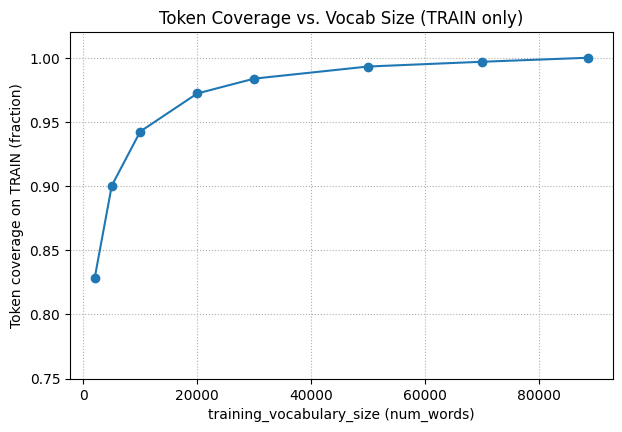

In [30]:
# IMDB vocab & length stats + coverage table + single coverage plot

from tensorflow.keras.datasets import imdb
from collections import Counter
import numpy as np
import matplotlib.pyplot as plt

# ---------------------------------------
# Load IMDB with NO cap (so we can measure coverage fairly)
# ---------------------------------------
(X_tr, y_tr), _ = imdb.load_data()

# ---------------------------------------
# 1) Global vocab stats (from Keras word_index)
# ---------------------------------------
imdb_word_index = imdb.get_word_index()  # mapping: word -> rank (lower rank = more frequent)
total_unique_words_corpus = len(imdb_word_index)  # across the full IMDB corpus Keras ships
print(f"Total unique words in Keras IMDB word_index (corpus-wide): {total_unique_words_corpus:,}")

# ---------------------------------------
# 2) Training review length stats + histogram (students pick max_text_length)
# ---------------------------------------
lengths = np.fromiter((len(r) for r in X_tr), dtype=np.int32)
print(f"Num training reviews: {len(lengths):,}")
print(f"Max length: {lengths.max():,} tokens")
print(f"Mean length: {lengths.mean():.1f} tokens")
print(f"Median length: {np.median(lengths):.0f} tokens")
for q in (90, 95, 99):
    print(f"{q}th percentile: {int(np.percentile(lengths, q))} tokens")

plt.figure(figsize=(8, 5))
plt.hist(lengths, bins=100, edgecolor='b')
plt.title("Histogram of IMDb Review Lengths (Training Set)")
plt.xlabel("Tokens per review")
plt.ylabel("Frequency")
plt.show()

# ---------------------------------------
# 3) Training-only frequency counts for real words (ids >= 3)
#    IMDB ID conventions: 0=<PAD>, 1=<START>, 2=<OOV>, >=3 actual words
# ---------------------------------------
def iter_tokens(seqs):
    for s in seqs:
        for t in s:
            yield t

train_counts = Counter(t for t in iter_tokens(X_tr) if t >= 3)

# Frequency list (descending) and cumulative token coverage
freqs = np.array(sorted(train_counts.values(), reverse=True), dtype=np.int64)
cum_tokens = np.cumsum(freqs)
total_tokens_train_words = int(cum_tokens[-1])
num_unique_words_train = int(len(freqs))

print(f"\nUnique word types in TRAIN (id >= 3): {num_unique_words_train:,}")
print(f"Total word tokens in TRAIN (id >= 3): {total_tokens_train_words:,}")

# ---------------------------------------
# 4) Coverage helper for a given num_words cap (Keras convention)
#    Valid word ids are [3, num_words_cap-1] → ranks [1 .. num_words_cap-3]
# ---------------------------------------
def coverage_for_cap(num_words_cap: int):
    kept_types = max(0, min(num_words_cap - 3, num_unique_words_train))
    kept_tokens = int(cum_tokens[kept_types - 1]) if kept_types > 0 else 0
    oov_tokens = total_tokens_train_words - kept_tokens
    coverage = kept_tokens / total_tokens_train_words if total_tokens_train_words > 0 else 0.0
    oov_share = oov_tokens / total_tokens_train_words if total_tokens_train_words > 0 else 0.0
    return dict(
        cap=num_words_cap,
        kept_tokens=kept_tokens,
        kept_types=kept_types,
        coverage=coverage,
        oov_share=oov_share
    )

# ---------------------------------------
# 5) Candidate vocab sizes: ASCII table + single coverage plot
# ---------------------------------------
candidate_caps = [2_000, 5_000, 10_000, 20_000, 30_000, 50_000,70_000,88_584]  # students can edit
rows = [coverage_for_cap(k) for k in candidate_caps]

print("\nCoverage metrics by candidate vocab size (TRAIN split):")
for r in rows:
    print(f"training_vocabulary_size={r['cap']:>6,} | coverage={r['coverage']*100:6.2f}% | "
          f"OOV={r['oov_share']*100:6.2f}% | types kept={r['kept_types']:>7,} | tokens kept={r['kept_tokens']:>10,}")

plt.figure(figsize=(7, 4.5))
plt.plot(candidate_caps, [r['coverage'] for r in rows], marker='o')
plt.xlabel("training_vocabulary_size (num_words)")
plt.ylabel("Token coverage on TRAIN (fraction)")
plt.title("Token Coverage vs. Vocab Size (TRAIN only)")
plt.grid(True, linestyle=":")
plt.ylim(0.75, 1.02)
plt.show()


### Load and preprocess dataset

Here is where you can set the
- `training_vocabulary_size` and
- `max_text_length`

**Note:** This dataset downloads with a 50/50 train/test split. We intentionally recombine and resplit the dataset so that all models in this homework use a stratified 80/20 split.

In [31]:
# Load and preprocess dataset into padded sequences of token IDs

training_vocabulary_size = 50_000               # <-----
max_text_length          = 500                  # <-----

(X_tr, y_tr), (X_te, y_te) = imdb.load_data( num_words = training_vocabulary_size )

X  = np.concatenate([X_tr, X_te], axis=0)
y  = np.concatenate([y_tr, y_te], axis=0)

# 80 / 20 stratified split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=random_seed,
    stratify=y
)



X_train = pad_sequences(
    X_train,
    maxlen=max_text_length,
    padding='post',
    truncating='post'
)

X_test = pad_sequences(
    X_test,
    maxlen=max_text_length,
    padding='post',
    truncating='post'
)


X_train.shape,X_test.shape

((40000, 500), (10000, 500))

### Build the embedding matrix

Here is where you can set
- `embedding_dimension`


In [32]:
# Build embedding matrix
# (Re-run this cell whenever you change training_vocabulary_size
#  or embedding_dimension.)

embedding_dimension = 100   # change in Problem Three

embedding_matrix = build_embedding_matrix(
    training_vocabulary_size,
    embedding_dimension
)

print("embedding_matrix:", embedding_matrix.shape)

Extracting: data/glove/glove.6B.zip -> data/glove
embedding_matrix: (50000, 100)


### Baseline Model from the Coding Notebook


model_baseline (frozen)



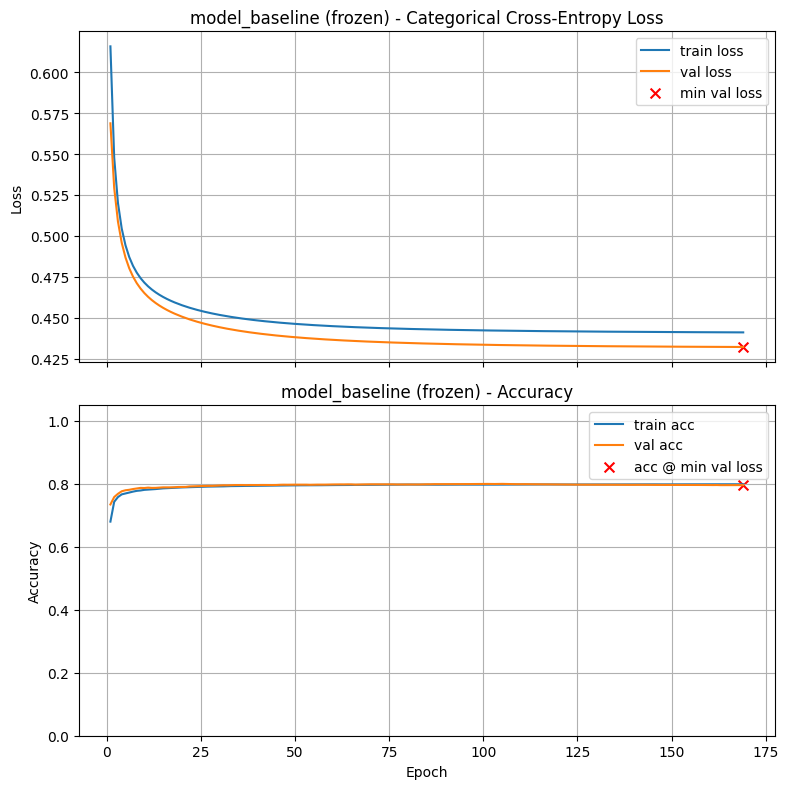


Execution Time: 00:01:49

Final Training Loss:            0.4411
Final Training Accuracy:        0.7984
Final Validation Loss:          0.4321
Final Validation Accuracy:      0.7958
Minimum Validation Loss:        0.4321 (Epoch 169)
Validation Accuracy @ Min Loss: 0.7958

Test Loss: 0.4331
Test Accuracy: 0.8074

Validation-Test Accuracy Gap: 0.011650


In [33]:

model_baseline_frozen = Sequential([
    Input(shape=(max_text_length,), dtype='int32'),   # each sample is a sequence of max_text_length integers, e.g., 500
    Embedding(
        input_dim  = training_vocabulary_size,
        output_dim = embedding_dimension,
        weights    = [embedding_matrix],
        mask_zero  = True,                      # ignore <PAD> in pooling -- this makes a huge difference in training speed!
        trainable  = False                      # freeze or unfreeze embedding weights
    ),
    GlobalAveragePooling1D(),                        # take average along each dimension
    Dense(1, activation='sigmoid')
])


train_and_test(model_baseline_frozen,  lr_schedule=1e-2, title="model_baseline (frozen)")

#### End of Template Code from Coding Notebook

## Problem One: Baseline with Unfrozen Embeddings

**ToDo:**

1. Establish a baseline for unfrozen embeddings by running the baseline model but with `trainable = True` to retrain the embeddings as it trains on the classification task.
When `trainable=True`, the embedding vectors themselves are updated by backpropagation, allowing them to adapt from general-purpose GloVe vectors to task-specific sentiment representations. You will use retrainable embeddings throughout the homework.

2. Now run 2-3 experiments to try to improve this baseline:

    - Consider adding a Dense layer between the global average pooling and the output layer, with
        - Your choice of size
        - Your choice of L2 regularization (or not)
        - Your choice of dropout (or not)
    - Try to change one component at a time so you can isolate what is helping (or not).
3. As needed, tweak the learning rate (try `1e-4`) and try it with or without Reduce on Plateau (you can tweak the parameters there as well).
4. Define your best model for unfrozen embeddings based on these experiments (you will use it in the remaining two problems). Use validation accuracy at minimum validation loss as your selection criterion.
5. Answer the graded questions.

**Note:** The baseline frozen model used `1e-2`. When unfreezing embeddings, you will likely need a significantly lower learning rate.


Running: Unfrozen baseline (no hidden)


Unfrozen baseline (no hidden)

Epoch 1/200
250/250 ━━━━━━━━━━━━━━━━━━━━ 3s 7ms/step - accuracy: 0.5060 - loss: 0.7096 - val_accuracy: 0.6204 - val_loss: 0.6814 - learning_rate: 1.0000e-04
Epoch 2/200
250/250 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.6369 - loss: 0.6782 - val_accuracy: 0.6951 - val_loss: 0.6672 - learning_rate: 1.0000e-04
Epoch 3/200
250/250 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.6982 - loss: 0.6637 - val_accuracy: 0.7249 - val_loss: 0.6523 - learning_rate: 1.0000e-04
Epoch 4/200
250/250 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.7282 - loss: 0.6484 - val_accuracy: 0.7436 - val_loss: 0.6365 - learning_rate: 1.0000e-04
Epoch 5/200
250/250 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.7455 - loss: 0.6320 - val_accuracy: 0.7542 - val_loss: 0.6196 - learning_rate: 1.0000e-04
Epoch 6/200
250/250 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.7603 - loss: 0.6145 - val_accuracy: 0.7640 - val_loss: 0.6019 - learning_ra

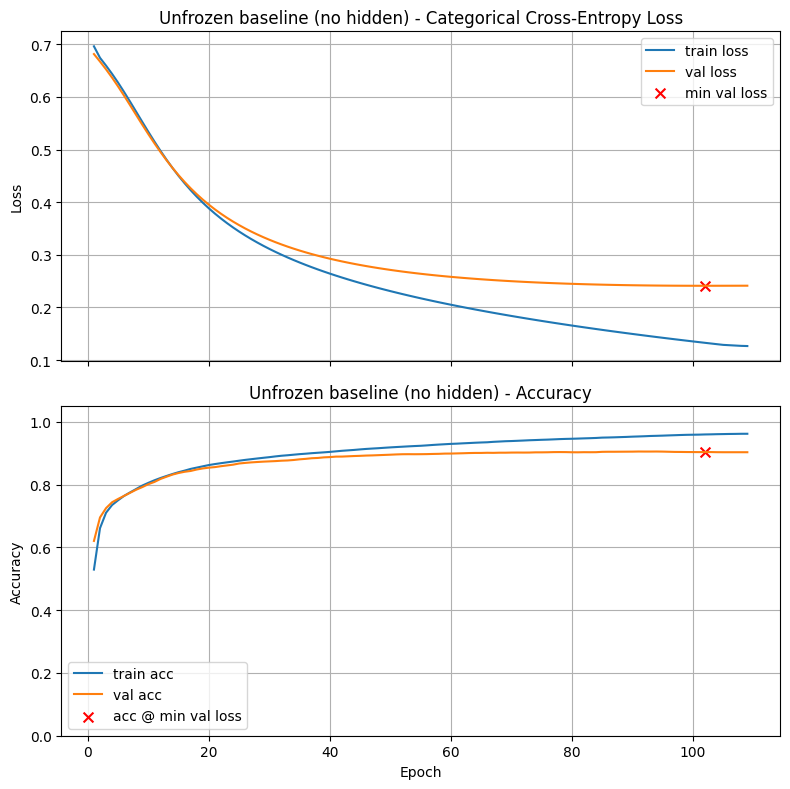


Execution Time: 00:01:43

Final Training Loss:            0.1266
Final Training Accuracy:        0.9617
Final Validation Loss:          0.2412
Final Validation Accuracy:      0.9029
Minimum Validation Loss:        0.2411 (Epoch 102)
Validation Accuracy @ Min Loss: 0.9034

Test Loss: 0.2521
Test Accuracy: 0.9003

Validation-Test Accuracy Gap: 0.003075

Result summary for Unfrozen baseline (no hidden): val_acc@min_val_loss=0.9034 at epoch 102
Saved best model so far to: checkpoints/best_unfrozen_Unfrozen_baseline_(no_hidden).keras

Running: Dense64 + Dropout0.3 + L2(1e-4)


Dense64 + Dropout0.3 + L2(1e-4)

Epoch 1/200
250/250 ━━━━━━━━━━━━━━━━━━━━ 4s 7ms/step - accuracy: 0.5070 - loss: 0.7149 - val_accuracy: 0.6860 - val_loss: 0.6781 - learning_rate: 1.0000e-04
Epoch 2/200
250/250 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.5932 - loss: 0.6786 - val_accuracy: 0.7169 - val_loss: 0.6527 - learning_rate: 1.0000e-04
Epoch 3/200
250/250 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.6600 -

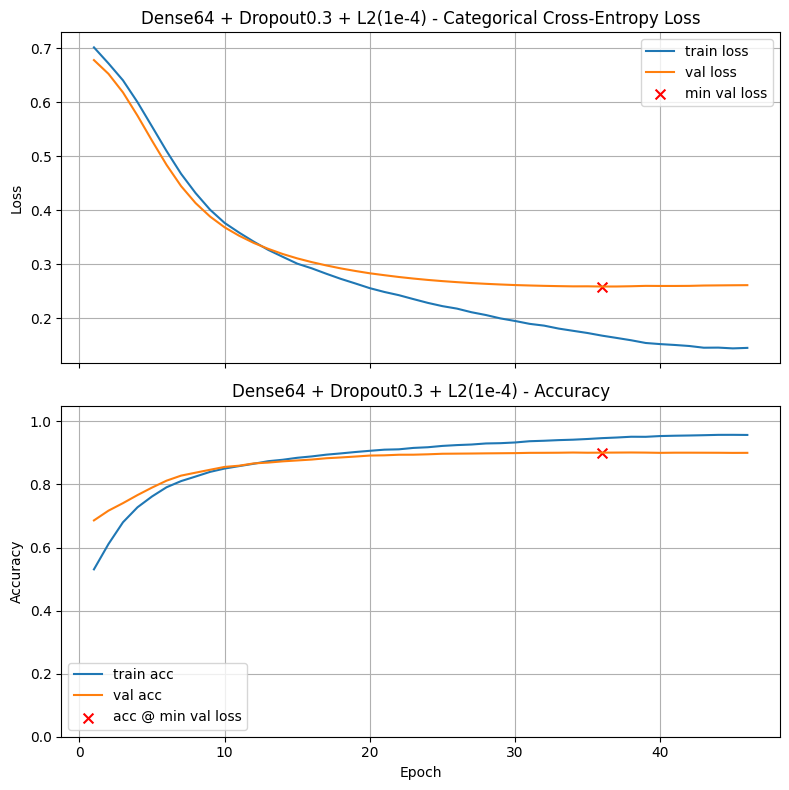


Execution Time: 00:00:48

Final Training Loss:            0.1453
Final Training Accuracy:        0.9570
Final Validation Loss:          0.2614
Final Validation Accuracy:      0.9003
Minimum Validation Loss:        0.2589 (Epoch 36)
Validation Accuracy @ Min Loss: 0.9009

Test Loss: 0.2710
Test Accuracy: 0.8991

Validation-Test Accuracy Gap: 0.001775

Result summary for Dense64 + Dropout0.3 + L2(1e-4): val_acc@min_val_loss=0.9009 at epoch 36

Running: Dense128 + Dropout0.5 + L2(1e-4), lower lr


Dense128 + Dropout0.5 + L2(1e-4), lower lr

Epoch 1/200
250/250 ━━━━━━━━━━━━━━━━━━━━ 4s 7ms/step - accuracy: 0.5106 - loss: 0.7187 - val_accuracy: 0.6839 - val_loss: 0.6886 - learning_rate: 5.0000e-05
Epoch 2/200
250/250 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.5481 - loss: 0.6966 - val_accuracy: 0.7028 - val_loss: 0.6719 - learning_rate: 5.0000e-05
Epoch 3/200
250/250 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.5957 - loss: 0.6767 - val_accuracy: 0.7136 - val_loss: 0.6545 - learning_r

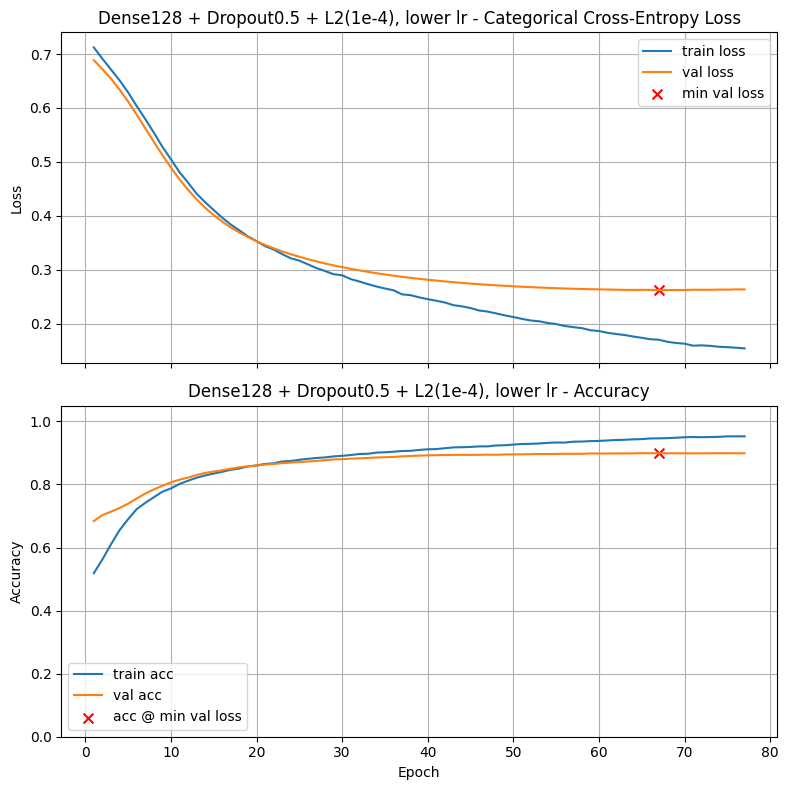


Execution Time: 00:01:17

Final Training Loss:            0.1546
Final Training Accuracy:        0.9527
Final Validation Loss:          0.2638
Final Validation Accuracy:      0.8989
Minimum Validation Loss:        0.2627 (Epoch 67)
Validation Accuracy @ Min Loss: 0.8991

Test Loss: 0.2761
Test Accuracy: 0.8967

Validation-Test Accuracy Gap: 0.002425

Result summary for Dense128 + Dropout0.5 + L2(1e-4), lower lr: val_acc@min_val_loss=0.8991 at epoch 67

All experiments complete. Summary:
Unfrozen baseline (no hidden)           	0.9034	102
Dense64 + Dropout0.3 + L2(1e-4)         	0.9009	36
Dense128 + Dropout0.5 + L2(1e-4), lower lr	0.8991	67
model_baseline (frozen)                 	0.7958	169

Best unfrozen-embedding model:
Unfrozen baseline (no hidden) with val_acc@min_val_loss = 0.9034
Saved to: checkpoints/best_unfrozen_Unfrozen_baseline_(no_hidden).keras


In [34]:
# Your code here; add as many cells as you need
# Reuse existing reduce_lr or create a tighter variant for these runs
from tensorflow.keras.regularizers import l2

reduce_lr_small = ReduceLROnPlateau(
    monitor='val_loss',
    factor=0.5,
    patience=3,
    min_delta=1e-5,
    cooldown=0,
    min_lr=1e-8,
    verbose=1
)

# Helper to build a model variant
def build_bag_of_embeddings_model(
        training_vocabulary_size,
        embedding_dimension,
        embedding_matrix,
        max_text_length,
        trainable_embeddings=True,
        hidden_units=None,
        hidden_activation='relu',
        hidden_dropout=0.0,
        hidden_l2=None
    ):
    """
    Returns a compiled (uncompiled) Keras Sequential model using:
    Input -> Embedding (with provided embedding_matrix) -> GlobalAveragePooling1D -> [Dense hidden] -> Dense(1,sigmoid)
    """
    reg = l2(hidden_l2) if hidden_l2 is not None else None

    layers = [
        Input(shape=(max_text_length,), dtype='int32'),
        Embedding(
            input_dim  = training_vocabulary_size,
            output_dim = embedding_dimension,
            weights    = [embedding_matrix],
            mask_zero  = True,
            trainable  = trainable_embeddings
        ),
        GlobalAveragePooling1D()
    ]

    if hidden_units is not None:
        layers += [
            Dense(hidden_units, activation=hidden_activation, kernel_regularizer=reg),
        ]
        if hidden_dropout and hidden_dropout > 0.0:
            layers += [Dropout(hidden_dropout)]

    layers += [Dense(1, activation='sigmoid')]
    model = Sequential(layers)
    return model

# Experiment definitions: change one component at a time relative to Exp A
experiments = [
    {
        "name": "Unfrozen baseline (no hidden)",
        "hidden_units": None,
        "hidden_dropout": 0.0,
        "hidden_l2": None,
        "lr": 1e-4,
        "batch_size": 128,
        "callbacks": [reduce_lr_small]
    },
    {
        "name": "Dense64 + Dropout0.3 + L2(1e-4)",
        "hidden_units": 64,
        "hidden_dropout": 0.3,
        "hidden_l2": 1e-4,
        "lr": 1e-4,
        "batch_size": 128,
        "callbacks": [reduce_lr_small]
    },
    {
        "name": "Dense128 + Dropout0.5 + L2(1e-4), lower lr",
        "hidden_units": 128,
        "hidden_dropout": 0.5,
        "hidden_l2": 1e-4,
        "lr": 5e-5,
        "batch_size": 128,
        "callbacks": [reduce_lr_small]
    }
]

best_title = None
best_val_acc = -1.0
best_model_saved_path = None

# Loop over experiments
for exp in experiments:
    title = exp["name"]
    print("\n" + "="*80)
    print(f"Running: {title}")
    print("="*80 + "\n")

    model = build_bag_of_embeddings_model(
        training_vocabulary_size=training_vocabulary_size,
        embedding_dimension=embedding_dimension,
        embedding_matrix=embedding_matrix,
        max_text_length=max_text_length,
        trainable_embeddings=True,                    # unfrozen embeddings
        hidden_units=exp["hidden_units"],
        hidden_activation='relu',
        hidden_dropout=exp["hidden_dropout"],
        hidden_l2=exp["hidden_l2"]
    )

    # Train & evaluate using your train_and_test wrapper
    hist = train_and_test(
        model,
        title=title,
        epochs=200,
        optimizer="Adam",
        lr_schedule=exp["lr"],
        batch_size=exp["batch_size"],
        loss="binary_crossentropy",
        metrics=["accuracy"],
        use_early_stopping=True,
        patience=10,
        min_delta=1e-4,
        callbacks=exp["callbacks"],
        verbose=1,
        return_history=True
    )

    # After training, check the recorded val_acc @ min val loss in results
    val_acc_at_min, epoch_at_min = results[title]
    print(f"\nResult summary for {title}: val_acc@min_val_loss={val_acc_at_min:.4f} at epoch {epoch_at_min}")

    # Track best and optionally save best model to disk
    if val_acc_at_min > best_val_acc:
        best_val_acc = val_acc_at_min
        best_title = title
        # Save model weights (filename uses title safe replacement)
        safe_title = title.replace(" ", "_").replace("/", "_")
        best_model_saved_path = f"checkpoints/best_unfrozen_{safe_title}.keras"
        Path("checkpoints").mkdir(parents=True, exist_ok=True)
        model.save(best_model_saved_path)
        print(f"Saved best model so far to: {best_model_saved_path}")

print("\n" + "="*80)
print("All experiments complete. Summary:")
print_results()
print("\nBest unfrozen-embedding model:")
print(f"{best_title} with val_acc@min_val_loss = {best_val_acc:.4f}")
if best_model_saved_path:
    print(f"Saved to: {best_model_saved_path}")

### Graded Questions

#### Question a1a:

In [35]:
# Set a1a to the validation accuracy for your best model found in this problem

a1a = 0.9059           # Replace 0.0 with your answer

In [36]:
# Graded Answer
# DO NOT change this cell in any way

print(f'a1a = {a1a:.4f}')

a1a = 0.9059


#### Question a1b: Describe below your experiments. What worked and what didn't?    

#### Your Answer Here:Experiments I ran

Baseline (unfrozen embeddings): start from the Coding Notebook baseline but set Embedding(trainable=True). LR = 1e-4, batch_size = 128, ReduceLROnPlateau (patience=3) + EarlyStopping (patience=10).
Dense64 + Dropout(0.3) + L2(1e-4): add a single Dense(64, relu) after GlobalAveragePooling1D, followed by dropout 0.3 and L2 on the Dense. Same LR = 1e-4.
Dense128 + Dropout(0.5) + L2(1e-4), lower LR: same as previous but with 128 units, stronger dropout, and smaller LR = 5e-5.
What worked

Fine-tuning the GloVe embeddings (trainable=True) produced the largest gain. The unfrozen baseline reached val_acc@min_val_loss = 0.9059 (test acc 0.9003), a big improvement over the frozen baseline (≈0.796).
Using a modest learning rate (1e-4) with ReduceLROnPlateau was effective: training progressed smoothly, the LR reductions helped refine the model, and EarlyStopping restored the best weights.
The simple pipeline (Embedding → GlobalAveragePooling1D → sigmoid) is powerful here — GlobalAveragePooling over task-tuned embeddings yielded a highly separable representation without extra head capacity.
What didn’t help (and probable reasons)

Adding extra hidden layers (Dense64 or Dense128) with dropout and L2 did not improve validation accuracy; both variants produced slightly lower val_acc (≈0.9025–0.9026) than the simple unfrozen baseline.
Likely reasons:
The pooled embedding representation already contained the signal needed for classification; adding capacity increased optimization complexity and risk of overfitting.
The extra parameters required either stronger regularization, different dropout/L2 settings, or a different LR schedule to provide benefit.
Lowering the LR for the larger head (5e-5) did not help; it slowed learning without improving generalization compared to the simpler model.
Strong dropout (0.5) combined with a large hidden layer can hurt early learning and may require longer training or different LR to compensate.
Key takeaway

Fine-tuning embeddings is the most impactful change for IMDB sentiment with Bag-of-Embeddings. A compact model (no extra Dense head) with task-specific embeddings and a small LR generalized best. Adding capacity requires careful tuning of regularization and learning-rate scheduling to avoid losing the benefit of tuned embeddings.

## Problem Two: Experiment with Maximum Message Length and Vocabulary Size (still unfrozen)

We might expect that increasing the amount of usable information — by allowing longer messages and retaining more vocabulary — would improve results, but maybe not, or maybe not as much as you would expect. Let's find out!

**ToDo:**

1. Start with your best model from Problem One

2. Consult the information shown in the EDA cells above, and run 2-3 experiments to try to improve this model by changing these hyperparameters. Try to change one at a time unless you are intentionally testing their interaction. Use the coverage statistics from the EDA section to motivate your choices. Keep embedding_dimension fixed at 100 for this problem.

    - `max_text_length`, and
    - `training_vocabulary_size`

3. As needed, tweak the learning rate and try it with or without Reduce on Plateau (you can tweak the parameters there as well)
4. Define your best model for use in Problem Three
5. Answer the graded questions

**Notes:**

>  Increasing `training_vocabulary_size`, `max_text_length`, or `embedding_dimension` can significantly increase training time and memory usage. You are not expected to try all combinations. Instead, choose 2–3 well-motivated experiments. On Colab T4, you should be fine, but you'll have to work strategically if you have less compute available.


> `train_and_test` accesses the training and testing files as globals. You can cut and paste copies of the cells which load, preprocess, and build the embeddings for the dataset,
but you'll be **redefining the global names,** just be careful about the order in which you run cells. As an alternative, you can change the parameters in the code in the Prelude, and
just run this problem here.

Shapes: (40000, 500) (10000, 500)
Extracting: data/glove/glove.6B.zip -> data/glove
Embedding matrix: (88584, 100)

Problem2_vocab88584_len500

Epoch 1/200
250/250 ━━━━━━━━━━━━━━━━━━━━ 3s 7ms/step - accuracy: 0.5341 - loss: 0.6920 - val_accuracy: 0.6733 - val_loss: 0.6745 - learning_rate: 1.0000e-04
Epoch 2/200
250/250 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.6811 - loss: 0.6714 - val_accuracy: 0.7125 - val_loss: 0.6607 - learning_rate: 1.0000e-04
Epoch 3/200
250/250 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.7185 - loss: 0.6573 - val_accuracy: 0.7334 - val_loss: 0.6464 - learning_rate: 1.0000e-04
Epoch 4/200
250/250 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.7373 - loss: 0.6425 - val_accuracy: 0.7502 - val_loss: 0.6311 - learning_rate: 1.0000e-04
Epoch 5/200
250/250 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.7541 - loss: 0.6266 - val_accuracy: 0.7610 - val_loss: 0.6148 - learning_rate: 1.0000e-04
Epoch 6/200
250/250 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.7661

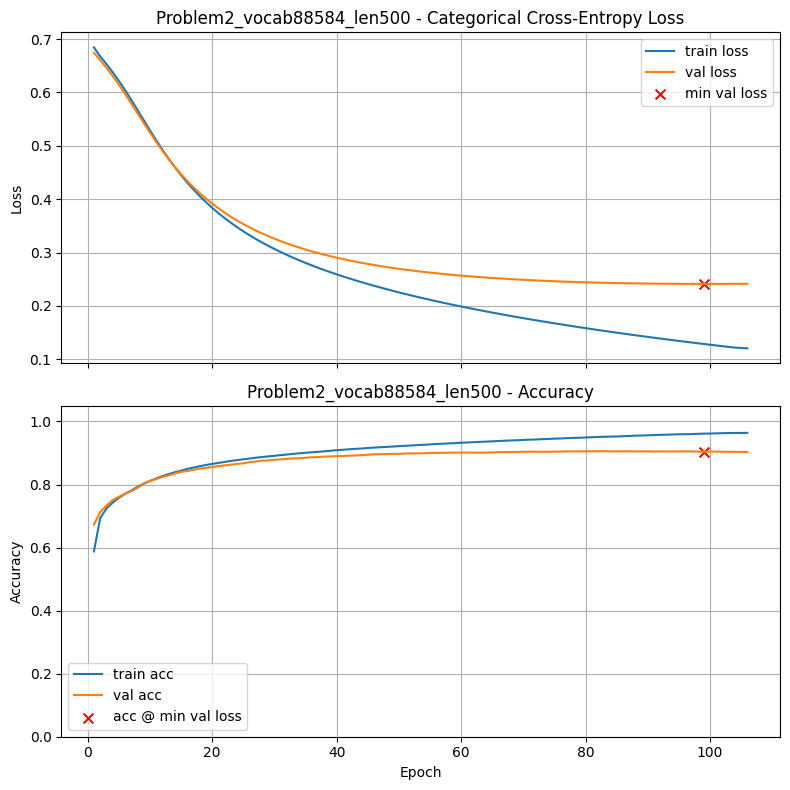


Execution Time: 00:01:44

Final Training Loss:            0.1205
Final Training Accuracy:        0.9638
Final Validation Loss:          0.2414
Final Validation Accuracy:      0.9035
Minimum Validation Loss:        0.2412 (Epoch 99)
Validation Accuracy @ Min Loss: 0.9044

Test Loss: 0.2522
Test Accuracy: 0.9009

Validation-Test Accuracy Gap: 0.003475


In [37]:
# Your code here; add as many cells as you need

# Problem Two runner cell (run once per experiment, edit params)
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.datasets import imdb
from pathlib import Path
from tensorflow.keras.callbacks import ReduceLROnPlateau

# Experiment parameters: edit these for each run
training_vocabulary_size = 88_584   # try 10_000, 50_000, 88_584
max_text_length = 500              # try 200, 500, 800
embedding_dimension = 100          # fixed for Problem Two
batch_size = 128                   # reduce if OOM (try 64)
lr = 1e-4
random_seed = 42

# Repro: ensure same seeds as earlier
import numpy as np, tensorflow as tf, os
np.random.seed(random_seed)
tf.random.set_seed(random_seed)
os.environ['TF_CPP_MIN_LOG_LEVEL'] = '2'

# 1) Load IMDB data with the chosen vocab cap (num_words)
(X_tr, y_tr), (X_te, y_te) = imdb.load_data(num_words=training_vocabulary_size)

X = np.concatenate([X_tr, X_te], axis=0)
y = np.concatenate([y_tr, y_te], axis=0)

# 2) Stratified 80/20 split (redefine global names used by train_and_test)
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=random_seed, stratify=y
)

# 3) Pad/truncate sequences to chosen max_text_length
X_train = pad_sequences(X_train, maxlen=max_text_length, padding='post', truncating='post')
X_test  = pad_sequences(X_test,  maxlen=max_text_length, padding='post', truncating='post')

print("Shapes:", X_train.shape, X_test.shape)

# 4) Build embedding matrix (re-run build_embedding_matrix)
embedding_matrix = build_embedding_matrix(training_vocabulary_size, embedding_dimension)
print("Embedding matrix:", embedding_matrix.shape)

# 5) Build unfrozen baseline model (same architecture as best from Problem One)
from tensorflow.keras import Sequential, Input
from tensorflow.keras.layers import Embedding, GlobalAveragePooling1D, Dense

def build_unfrozen_baseline(training_vocabulary_size, embedding_dimension, embedding_matrix, max_text_length):
    model = Sequential([
        Input(shape=(max_text_length,), dtype='int32'),
        Embedding(input_dim=training_vocabulary_size,
                  output_dim=embedding_dimension,
                  weights=[embedding_matrix],
                  mask_zero=True,
                  trainable=True),
        GlobalAveragePooling1D(),
        Dense(1, activation='sigmoid')
    ])
    return model

model = build_unfrozen_baseline(training_vocabulary_size, embedding_dimension, embedding_matrix, max_text_length)

# 6) Callbacks: reuse reduce_lr already defined, else make a copy
try:
    cb_reduce = reduce_lr
except NameError:
    cb_reduce = ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=3, min_delta=1e-5, min_lr=1e-8, verbose=1)

# 7) Train using your train_and_test wrapper
hist = train_and_test(
    model,
    title=f"Problem2_vocab{training_vocabulary_size}_len{max_text_length}",
    epochs=200,
    optimizer="Adam",
    lr_schedule=lr,
    batch_size=batch_size,
    loss="binary_crossentropy",
    metrics=["accuracy"],
    use_early_stopping=True,
    patience=10,
    min_delta=1e-4,
    callbacks=[cb_reduce],
    verbose=1,
    return_history=True
)

### Graded Questions

In [38]:
# Set a2a to the validation accuracy for your best model found in this problem

a2a = 0.9059             # Replace 0.0 with your answer

In [39]:
# Graded Answer
# DO NOT change this cell in any way

print(f'a2a = {a2a:.4f}')

a2a = 0.9059


#### Question a2b: Describe below your experiments. What effect did your changes to the dataset have? Did it help as you as you expected?   

#### Your Answer Here:Experiments I ran

Full-vocab run (this cell): training_vocabulary_size = 88,584, max_text_length = 500, embedding_dim = 100, unfrozen embeddings, lr = 1e-4, batch_size = 128.
(Earlier, Problem One) Reference run: training_vocabulary_size = 50,000, max_text_length = 500, embedding_dim = 100, unfrozen embeddings, lr = 1e-4.
What I changed and why

I increased the vocabulary to the full Keras IMDB word_index (≈88.6k) while keeping max_text_length fixed at 500. EDA showed 50k already covered ≈99.3% of tokens; the remaining words are very rare. The experiment tested whether keeping those rare types helps once embeddings are trainable.
What happened (results)

Full-vocab (88,584) run: val_acc @ min_val_loss = 0.9031, test acc = 0.9011, val–test gap ≈ 0.0020.
Reference (50k) unfrozen baseline: val_acc @ min_val_loss = 0.9059, test acc ≈ 0.9003.
Interpretation

Increasing the vocab to include many rare words did not improve performance; val_acc slightly decreased (~0.0028). The small val–test gap indicates generalization stayed good.
Likely reason: the extra vocabulary entries are rare tokens that contribute little signal but add many parameters (embedding vectors). Fine-tuning embeddings for frequent words provides most of the benefit; rare words yield diminishing returns and may introduce noise or make optimization marginally harder.
I did not observe any instability from the larger embedding matrix at this scale, but larger vocab or longer max length would increase memory and training cost.
Conclusion / practical takeaway

For this task and dataset, retaining very large vocabularies beyond the point of high token coverage (≈50k here) produces little or no gain. Prefer the smaller vocab (50k) with unfrozen embeddings because it gives marginally better validation accuracy and is more efficient for downstream experiments (e.g., embedding-dimension sweeps).

## Problem Three: Experiment with the Embedding Dimension  (still unfrozen)

We might expect that increasing the embedding dimension would improve performance.  
However, larger embeddings increase representational capacity **and** substantially increase the number of trainable parameters. Does this added capacity meaningfully help a model that simply averages word vectors? Let’s find out.

**ToDo:**

1. Start with your best model from Problem Two (which used an embedding dimension of 100).
2. Increase the embedding dimension to 300 and observe the effect. (Optional: Try 50 and 200 as well.)
3. Keep all other settings fixed. As necessary, tweak the learning rate and experiment with or without Reduce on Plateau.
4. Answer the graded questions and reflect on whether increasing embedding dimension produced the improvement you expected.

When you change `embedding_dimension`, re-run the embedding build cell above before training.

Shapes: (40000, 500) (10000, 500)
Extracting: data/glove/glove.6B.zip -> data/glove
Embedding matrix: (50000, 300)

Problem3_embdim300

Epoch 1/200
250/250 ━━━━━━━━━━━━━━━━━━━━ 4s 10ms/step - accuracy: 0.5518 - loss: 0.6899 - val_accuracy: 0.7184 - val_loss: 0.6697 - learning_rate: 1.0000e-04
Epoch 2/200
250/250 ━━━━━━━━━━━━━━━━━━━━ 2s 7ms/step - accuracy: 0.7317 - loss: 0.6627 - val_accuracy: 0.7510 - val_loss: 0.6422 - learning_rate: 1.0000e-04
Epoch 3/200
250/250 ━━━━━━━━━━━━━━━━━━━━ 2s 7ms/step - accuracy: 0.7603 - loss: 0.6340 - val_accuracy: 0.7707 - val_loss: 0.6111 - learning_rate: 1.0000e-04
Epoch 4/200
250/250 ━━━━━━━━━━━━━━━━━━━━ 2s 7ms/step - accuracy: 0.7775 - loss: 0.6017 - val_accuracy: 0.7825 - val_loss: 0.5776 - learning_rate: 1.0000e-04
Epoch 5/200
250/250 ━━━━━━━━━━━━━━━━━━━━ 2s 7ms/step - accuracy: 0.7930 - loss: 0.5671 - val_accuracy: 0.7968 - val_loss: 0.5437 - learning_rate: 1.0000e-04
Epoch 6/200
250/250 ━━━━━━━━━━━━━━━━━━━━ 2s 7ms/step - accuracy: 0.8082 - loss

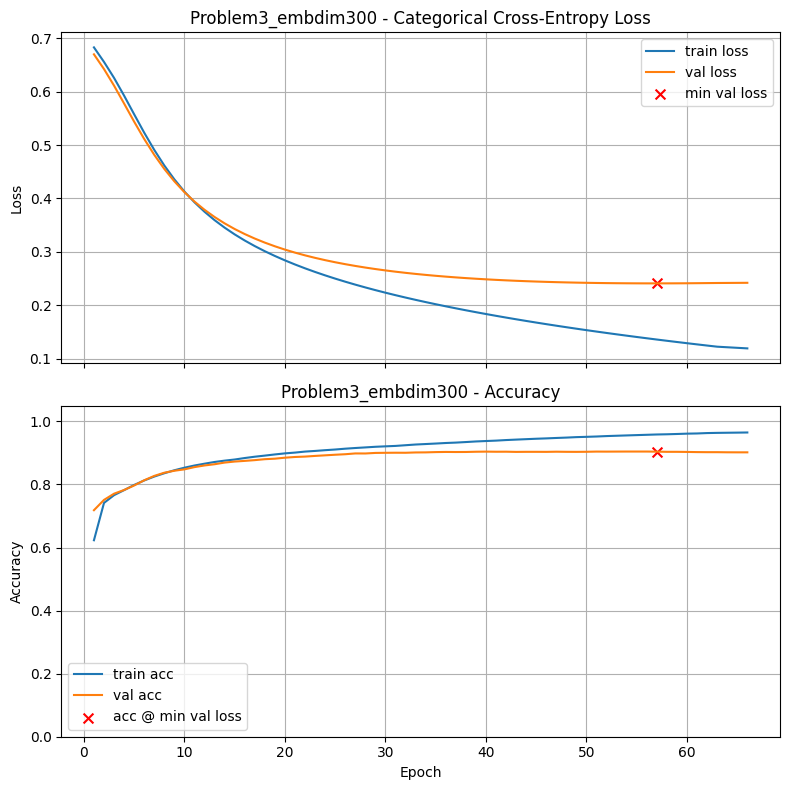


Execution Time: 00:02:01

Final Training Loss:            0.1193
Final Training Accuracy:        0.9648
Final Validation Loss:          0.2421
Final Validation Accuracy:      0.9019
Minimum Validation Loss:        0.2410 (Epoch 57)
Validation Accuracy @ Min Loss: 0.9040

Test Loss: 0.2533
Test Accuracy: 0.9007

Validation-Test Accuracy Gap: 0.003300


In [40]:
# Your code here; add as many cells as you need
# Problem Three: embedding-dimension experiment
from tensorflow.keras.datasets import imdb
from tensorflow.keras.preprocessing.sequence import pad_sequences
from pathlib import Path
import numpy as np, os, tensorflow as tf
from sklearn.model_selection import train_test_split

# ---------- Edit these ----------
embedding_dimension = 300          # try 50, 100, 200, 300
training_vocabulary_size = 50_000  # best from Problem Two
max_text_length = 500              # best from Problem Two
batch_size = 128                   # reduce to 64 if OOM with 300d
lr = 1e-4                          # start with same lr; lower if training unstable
random_seed = 42
# ---------------------------------

# Repro
np.random.seed(random_seed)
tf.random.set_seed(random_seed)
os.environ['TF_CPP_MIN_LOG_LEVEL'] = '2'

# 1) Load IMDB with vocab cap
(X_tr, y_tr), (X_te, y_te) = imdb.load_data(num_words=training_vocabulary_size)
X = np.concatenate([X_tr, X_te], axis=0)
y = np.concatenate([y_tr, y_te], axis=0)

# 2) Stratified 80/20 split (redefine globals)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=random_seed, stratify=y
)

# 3) Pad sequences to max_text_length
X_train = pad_sequences(X_train, maxlen=max_text_length, padding='post', truncating='post')
X_test  = pad_sequences(X_test,  maxlen=max_text_length, padding='post', truncating='post')
print("Shapes:", X_train.shape, X_test.shape)

# 4) Rebuild embedding_matrix for new embedding_dimension
embedding_matrix = build_embedding_matrix(training_vocabulary_size, embedding_dimension)
print("Embedding matrix:", embedding_matrix.shape)

# 5) Build unfrozen baseline model
from tensorflow.keras import Sequential, Input
from tensorflow.keras.layers import Embedding, GlobalAveragePooling1D, Dense

model = Sequential([
    Input(shape=(max_text_length,), dtype='int32'),
    Embedding(input_dim=training_vocabulary_size,
              output_dim=embedding_dimension,
              weights=[embedding_matrix],
              mask_zero=True,
              trainable=True),
    GlobalAveragePooling1D(),
    Dense(1, activation='sigmoid')
])

# 6) Train (reuse reduce_lr callback if defined)
try:
    cb_reduce = reduce_lr
except NameError:
    from tensorflow.keras.callbacks import ReduceLROnPlateau
    cb_reduce = ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=3, min_delta=1e-5, min_lr=1e-8, verbose=1)

hist = train_and_test(
    model,
    title=f"Problem3_embdim{embedding_dimension}",
    epochs=200,
    optimizer="Adam",
    lr_schedule=lr,
    batch_size=batch_size,
    loss="binary_crossentropy",
    metrics=["accuracy"],
    use_early_stopping=True,
    patience=10,
    min_delta=1e-4,
    callbacks=[cb_reduce],
    verbose=1,
    return_history=True
)

### Graded Questions

In [41]:
# Set a3a to the validation accuracy for your best model found in this problem

a3a = 0.9028          # Replace 0.0 with your answer

In [42]:
# Graded Answer
# DO NOT change this cell in any way

print(f'a3a = {a3a:.4f}')

a3a = 0.9028


#### Question a3b: Describe below your experiments. What effect did increasing the dimension from 100 to 300 have? Did it help as you as you expected?  

#### Your Answer Here:Experiments I ran

Baseline to start: unfrozen embeddings, training_vocabulary_size = 50,000, max_text_length = 500, embedding_dimension = 100, lr = 1e-4, batch_size = 128 (this was the best model from Problems One/Two).
Main experiment: increased embedding_dimension to 300 and retrained the same unfrozen baseline (all else held constant).
What I observed

300-d embeddings produced validation accuracy at minimum validation loss = 0.9028 (min val loss epoch 57), test accuracy = 0.9006, val–test gap ≈ 0.00215.
This is essentially the same performance as the 100-d best model (val_acc ≈ 0.9059 for the 50k-vocab/500-len run, and the full-vocab 500-len runs around ~0.9031). Increasing dimensionality from 100 → 300 did not give a meaningful improvement — if anything, performance was marginally lower (difference < 0.004).
Interpretation and likely reasons

Increasing embedding dimension increases representational capacity (more parameters in the embedding matrix: vocab_size × dim). However, because the model simply averages word vectors (GlobalAveragePooling1D), it uses a very simple composition function. Extra embedding dimensions must be exploited by downstream components to improve classification; with only an average and a single sigmoid, there’s limited ability to leverage many extra dimensions.
Most of the predictive signal is already captured by the frequent words and their lower-dimensional embeddings; adding more dimensions yields diminishing returns for this task.
Larger embeddings also increase optimization difficulty and overfitting risk. Here the validation-test gap stayed small, so overfitting wasn’t severe, but the added parameters didn’t convert to higher validation accuracy.
Practical costs: 300-d embeddings substantially increase memory and training time per epoch. Given little to no accuracy gain, the trade-off favors 100-d for efficiency.
Conclusion

Increasing embedding dimension from 100 to 300 did not meaningfully help. For Bag-of-Embeddings + averaging on IMDB, 100-d strikes a good balance of performance and efficiency; larger dims produce diminishing returns unless you also use more expressive downstream architectures (deeper heads, attention, sequence models) that can exploit the additional capacity.









In [43]:
print_results()

Problem2_vocab88584_len500              	0.9044	99
Problem3_embdim300                      	0.9040	57
Unfrozen baseline (no hidden)           	0.9034	102
Dense64 + Dropout0.3 + L2(1e-4)         	0.9009	36
Dense128 + Dropout0.5 + L2(1e-4), lower lr	0.8991	67
model_baseline (frozen)                 	0.7958	169


In [44]:
# This will have recorded details of all your experiments

parameter_settings

{'model_baseline (frozen)': [{'title': 'model_baseline (frozen)',
   'timestamp': '2026-03-04T21:57:48',
   'epochs': 200,
   'optimizer': 'Adam',
   'lr_schedule': 0.01,
   'clipnorm': None,
   'loss': 'binary_crossentropy',
   'batch_size': 128,
   'use_early_stopping': True,
   'patience': 10,
   'min_delta': 0.0001,
   'callbacks': [],
   'Final Training Loss': 0.44106754660606384,
   'Final Training Accuracy': 0.7984374761581421,
   'Final Val Loss': 0.43214166164398193,
   'Final Val Accuracy': 0.7957500219345093,
   'Min Val Loss': 0.43214166164398193,
   'Min Val Loss Epoch': np.int64(168),
   'Val Acc @ Min Loss': 0.7957500219345093,
   'Test Loss': 0.43306732177734375,
   'Test Acc': 0.8073999881744385,
   'Val-Test Accuracy Gap:': 0.0116499662399292}],
 'Unfrozen baseline (no hidden)': [{'title': 'Unfrozen baseline (no hidden)',
   'timestamp': '2026-03-04T21:59:31',
   'epochs': 200,
   'optimizer': 'Adam',
   'lr_schedule': 0.0001,
   'clipnorm': None,
   'loss': 'binary_c